In [1]:
import sys

sys.path.append("..")

import torch
import matplotlib.pyplot as plt
import numpy as np

from src.paths import Paths
from src.utils import (
    get_device,
    tensor_to_img,
    plot_image,
    initialize_resnet18,
    load_model_weights,
)
from src.data_manager import DataManager
from src.perturbations import Perturbations
from src import config
from src.explainers import IGExplainer, OcclusionExplainer
from src.xai_experiment import XAIExperiment

## Konfiguracja ogólna

In [2]:
dataset_name = "cifar10"

device = get_device()
empty_model = initialize_resnet18(pretrained=False)

paths = Paths()

model = load_model_weights(empty_model, paths.CIFAR10_MODEL, device)

data_manager = DataManager(paths.DATA_DIR)

test_data = data_manager.get_test_dataset(dataset_name=dataset_name, download=False)
class_names = data_manager.get_class_names(dataset_name=dataset_name)

perturbations = Perturbations(model=model, device=device)
epsilon = 0.8

/home/mikolajmalolepszy/Desktop/Projects/mgr/.venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


## Wybór badanych przykładów

In [3]:
selected_classes = [0, 1, 2, 3]
min_confidence = 0.99
max_examples_per_class = 10

clean_examples = {class_id: [] for class_id in selected_classes}


for image, label in test_data:
    if label not in selected_classes:
        continue

    if len(clean_examples[label]) >= max_examples_per_class:
        continue

    tensor = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(tensor)
        probs = torch.softmax(output, dim=1)

        pred = output.argmax(dim=1).item()
        conf = probs[0, pred].item()

    if pred == label and conf >= min_confidence:
        clean_examples[label].append(image)

    if all(
        len(clean_examples[class_id]) >= max_examples_per_class
        for class_id in selected_classes
    ):
        break


In [4]:
chosen_indices = {
    0: 0,
    1: 0,
    2: 7,
    3: 9,
}

clean_examples_vis = {
    class_id: clean_examples[class_id][chosen_indices[class_id]]
    for class_id in selected_classes
}

## Konfiguracja IG

In [5]:
ig_explainer = IGExplainer(model=model, device=device, config=config.IGConfig())
ig_experiment = XAIExperiment(
    model=model,
    device=device,
    class_names=class_names,
    clean_examples=clean_examples,
    explainer=ig_explainer,
    perturbations=perturbations,
)
ig_experiment_vis = XAIExperiment(
    model=model,
    device=device,
    class_names=class_names,
    clean_examples=clean_examples_vis,
    explainer=ig_explainer,
    perturbations=perturbations,
)

ig_classes = ig_experiment_vis.selected_classes

all_ig_attrs = []
for class_id in ig_classes:
    clean_tensor = ig_experiment_vis.get_clean_tensor(class_id)
    noised_tensor = ig_experiment_vis.get_perturbed_tensor(
        clean_tensor=clean_tensor,
        class_id=class_id,
        perturbation_type="fgsm",
        value=epsilon,
    )

    clean_attr = ig_experiment_vis.explainer.explain(
        input_tensor=clean_tensor, target_class=class_id
    )["abs"]

    noised_attr = ig_experiment_vis.explainer.explain(
        input_tensor=noised_tensor, target_class=class_id
    )["abs"]

    all_ig_attrs.append(clean_attr)
    all_ig_attrs.append(noised_attr)

ig_vmin = 0
ig_vmax = np.percentile([attr.flatten() for attr in all_ig_attrs], 99.9)


## Niezaatakowane dane

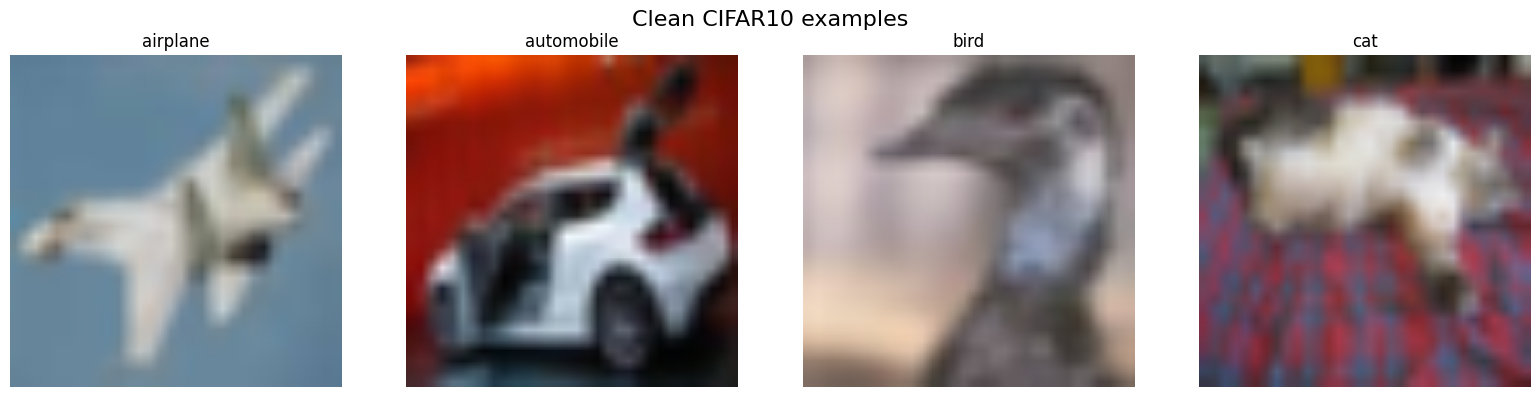

In [6]:
fig, axes = plt.subplots(
    1,
    len(selected_classes),
    figsize=(4 * len(selected_classes), 4),
)

fig.suptitle("Clean CIFAR10 examples", fontsize=16)

for idx, class_id in enumerate(selected_classes):
    clean_tensor = clean_examples_vis[class_id].unsqueeze(0)

    plot_image(
        axes[idx],
        tensor_to_img(clean_tensor),
        title=f"{class_names[class_id]}",
        cmap=None,
    )

plt.tight_layout()
plt.show()

## IG dla niezaatakowanych danych

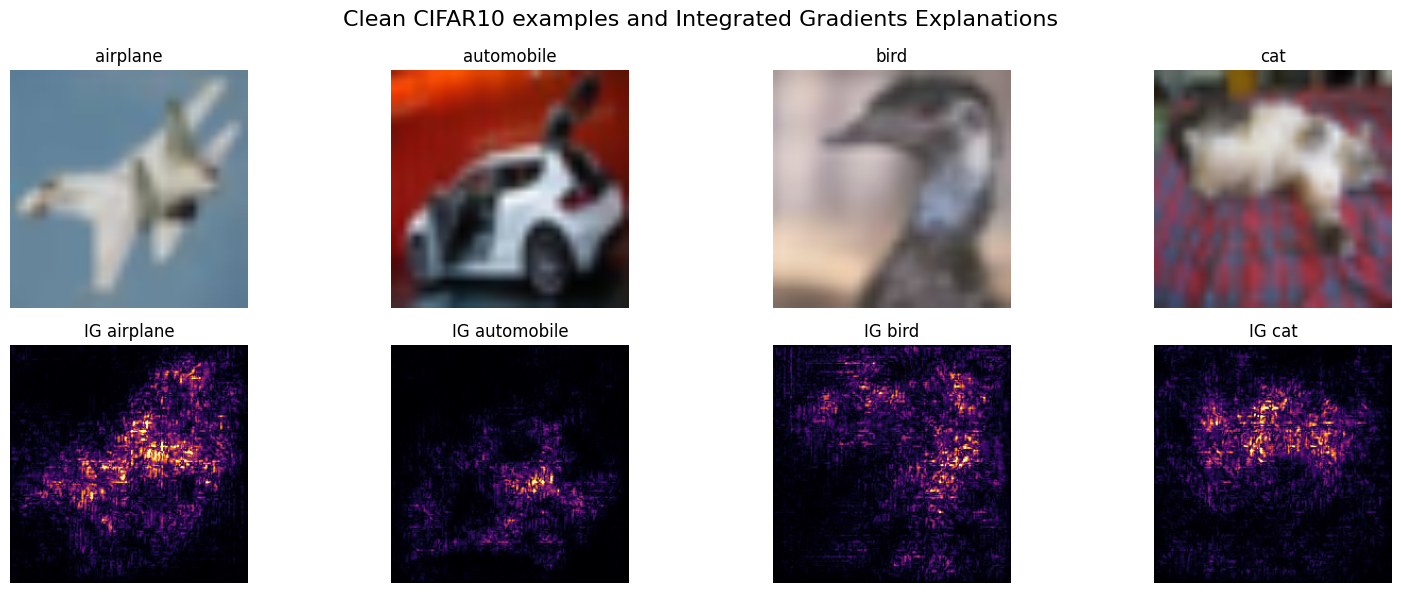

In [7]:
fig, axes = plt.subplots(
    2,
    len(selected_classes),
    figsize=(4 * len(selected_classes), 6),
)

fig.suptitle(
    "Clean CIFAR10 examples and Integrated Gradients Explanations",
    fontsize=16,
)

for col, class_id in enumerate(selected_classes):
    clean_tensor = clean_examples_vis[class_id].unsqueeze(0).to(device)
    clean_img = tensor_to_img(clean_tensor)

    attr_ig = ig_experiment_vis.explainer.explain(
        input_tensor=clean_tensor,
        target_class=class_id,
    )["abs"]

    plot_image(
        axes[0, col],
        clean_img,
        title=f"{class_names[class_id]}",
        cmap=None,
    )

    plot_image(
        axes[1, col],
        attr_ig,
        title=f"IG {class_names[class_id]}",
        cmap="inferno",
        vmin=ig_vmin,
        vmax=ig_vmax,
    )

plt.tight_layout()
plt.show()

## Szum Gaussa - prezentacja

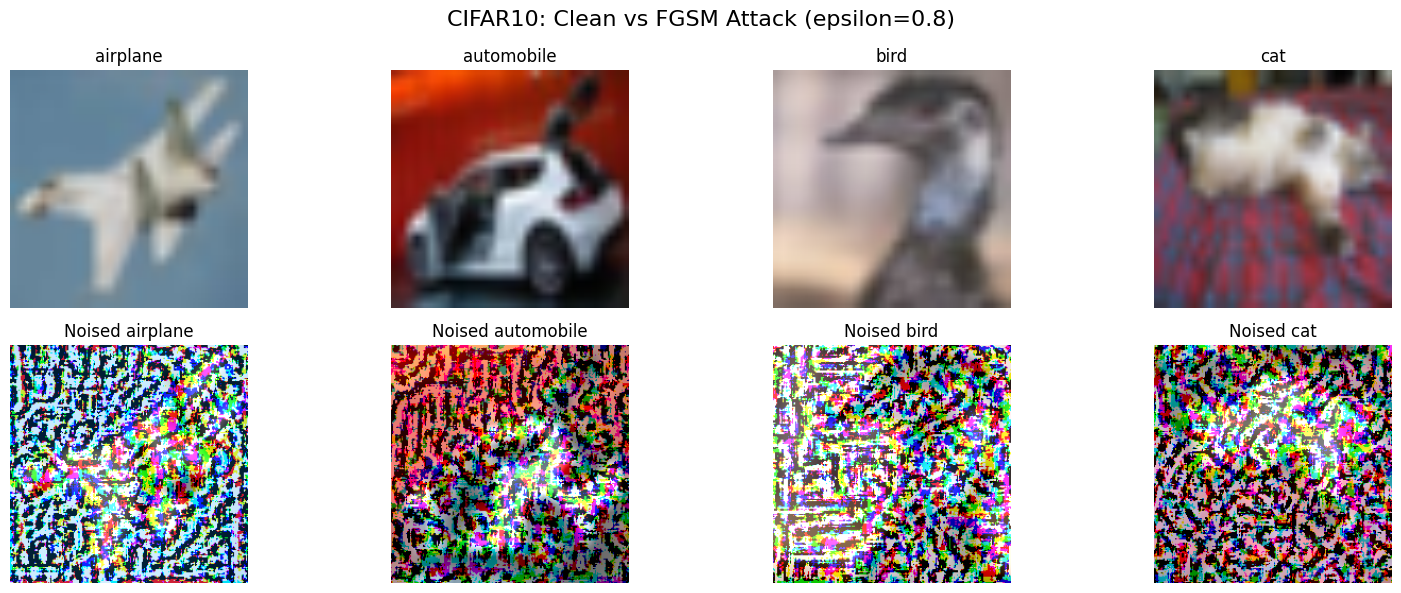

In [ ]:
fig, axes = plt.subplots(
    2,
    len(selected_classes),
    figsize=(4 * len(selected_classes), 6),
)

fig.suptitle(
    f"CIFAR10: Clean vs FGSM Attack (epsilon={epsilon})",
    fontsize=16,
)

for col, class_id in enumerate(selected_classes):
    clean_tensor = clean_examples_vis[class_id].unsqueeze(0)

    noised_tensor = perturbations.fgsm(
        input_tensor=clean_tensor,
        target_class=class_id,
        epsilon=epsilon,
    )

    plot_image(
        axes[0, col],
        tensor_to_img(clean_tensor),
        title=f"{class_names[class_id]}",
        cmap=None,
    )

    plot_image(
        axes[1, col],
        tensor_to_img(noised_tensor),
        title=f"Attacked {class_names[class_id]}",
        cmap=None,
    )

plt.tight_layout()
plt.show()

## IG danych niezaszumionych oraz zaszumionych

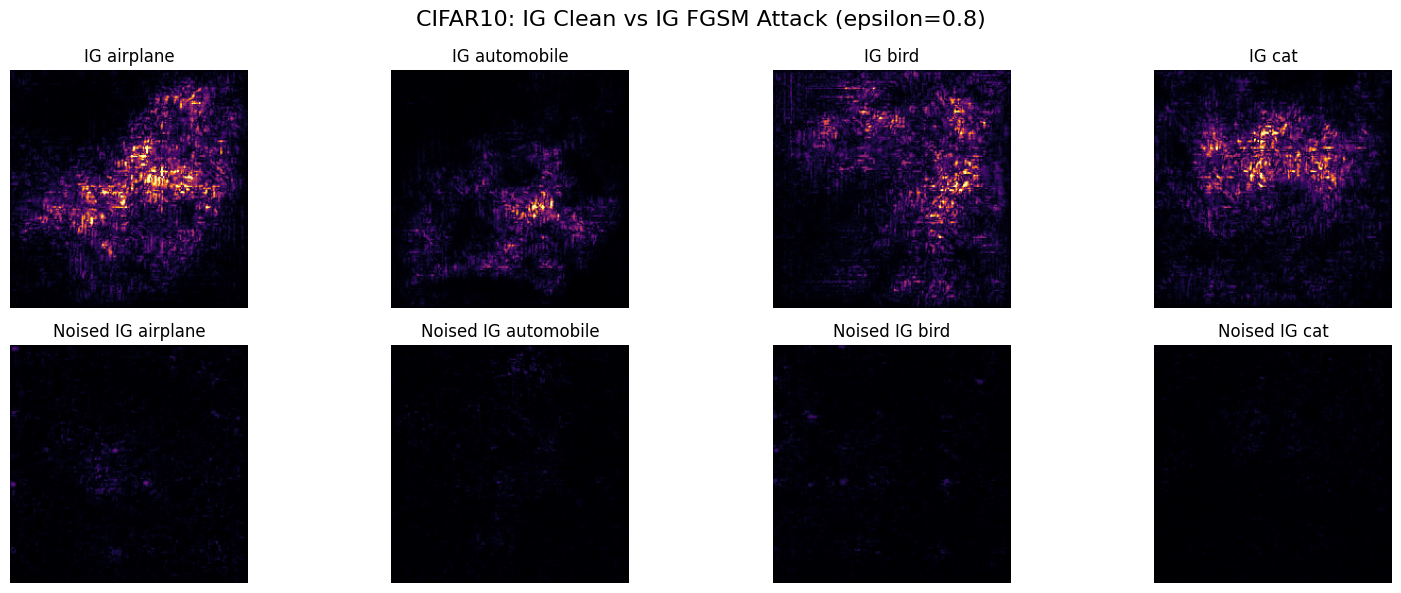

In [ ]:
fig, axes = plt.subplots(
    2,
    len(selected_classes),
    figsize=(4 * len(selected_classes), 6),
)

fig.suptitle(
    f"CIFAR10: IG Clean vs IG FGSM Attack (epsilon={epsilon})",
    fontsize=16,
)

for col, class_id in enumerate(selected_classes):
    clean_tensor = clean_examples_vis[class_id].unsqueeze(0).to(device)

    noised_tensor = ig_experiment_vis.perturbations.fgsm(
        input_tensor=clean_tensor,
        target_class=class_id,
        epsilon=epsilon,
    )

    clean_attr = ig_experiment_vis.explainer.explain(
        input_tensor=clean_tensor,
        target_class=class_id,
    )["abs"]

    noised_attr = ig_experiment_vis.explainer.explain(
        input_tensor=noised_tensor,
        target_class=class_id,
    )["abs"]

    plot_image(
        axes[0, col],
        clean_attr,
        title=f"IG {class_names[class_id]}",
        cmap="inferno",
        vmin=ig_vmin,
        vmax=ig_vmax,
    )

    plot_image(
        axes[1, col],
        noised_attr,
        title=f"Attacked IG {class_names[class_id]}",
        cmap="inferno",
        vmin=ig_vmin,
        vmax=ig_vmax,
    )

plt.tight_layout()
plt.show()

## Cosine Similarity oraz TopK IoU (IG)

In [11]:
df_similarity = ig_experiment.run_similarity_metrics(
    perturbation_type="fgsm",
    values=config.ExperimentConfig().fgsm_epsilons,
)

display(
    ig_experiment.make_pivot(
        df_similarity,
        "CosineSimilarity",
    ).round(3)
)

display(
    ig_experiment.make_pivot(
        df_similarity,
        "TopK_IoU",
    ).round(3)
)

display(ig_experiment.summarize_similarity(df_similarity).round(3))

Processing fgsm=0.01
Processing fgsm=0.03
Processing fgsm=0.05
Processing fgsm=0.075
Processing fgsm=0.1
Processing fgsm=0.15
Processing fgsm=0.2
Processing fgsm=0.3
Processing fgsm=0.4
Processing fgsm=0.5


ClassName,airplane,automobile,bird,cat
Value,,,,
0.010,0.754,0.803,0.714,0.744
0.030,0.625,0.663,0.625,0.625
0.050,0.595,0.622,0.609,0.609
0.075,0.574,0.596,0.595,0.596
0.100,0.559,0.582,0.590,0.577
0.150,0.533,0.560,0.562,0.553
0.200,0.509,0.543,0.532,0.540
0.300,0.474,0.524,0.490,0.524
0.400,0.457,0.508,0.462,0.512


ClassName,airplane,automobile,bird,cat
Value,,,,
0.010,0.299,0.384,0.290,0.293
0.030,0.176,0.232,0.209,0.192
0.050,0.155,0.193,0.190,0.183
0.075,0.138,0.173,0.173,0.175
0.100,0.126,0.160,0.166,0.161
0.150,0.109,0.148,0.142,0.134
0.200,0.096,0.141,0.120,0.119
0.300,0.079,0.131,0.094,0.108
0.400,0.072,0.117,0.089,0.101


,Value,CosineMean,CosineStd,TopKIoUMean,TopKIoUStd
0,0.010,0.754,0.052,0.316,0.075
1,0.030,0.634,0.044,0.202,0.058
2,0.050,0.609,0.043,0.180,0.051
3,0.075,0.590,0.044,0.165,0.052
4,0.100,0.577,0.045,0.153,0.050
5,0.150,0.552,0.052,0.133,0.046
6,0.200,0.531,0.055,0.119,0.048
7,0.300,0.503,0.057,0.103,0.048
8,0.400,0.485,0.056,0.095,0.043
9,0.500,0.466,0.053,0.088,0.037


## Deletion AUC (IG)

In [ ]:
df_deletion = ig_experiment.run_deletion_auc(
    perturbation_type="fgsm",
    values=config.ExperimentConfig().fgsm_epsilons,
)

display(
    ig_experiment.make_pivot(
        df_deletion,
        "DeletionAUC_Perturbed",
    ).round(3)
)

display(ig_experiment.summarize_deletion(df_deletion).round(3))

Processing fgsm=0.01
Processing fgsm=0.03
Processing fgsm=0.05


## Konfiguracja Occlusion

In [5]:
occ_explainer = OcclusionExplainer(
    model=model, device=device, config=config.OcclusionConfig(), dataset="cifar10"
)
occ_experiment = XAIExperiment(
    model=model,
    device=device,
    class_names=class_names,
    clean_examples=clean_examples,
    explainer=occ_explainer,
    perturbations=perturbations,
)
occ_experiment_vis = XAIExperiment(
    model=model,
    device=device,
    class_names=class_names,
    clean_examples=clean_examples_vis,
    explainer=occ_explainer,
    perturbations=perturbations,
)

occ_classes = occ_experiment_vis.selected_classes

all_occ_attrs = []
for class_id in occ_classes:
    clean_tensor = occ_experiment_vis.get_clean_tensor(class_id)
    noised_tensor = occ_experiment_vis.get_perturbed_tensor(
        clean_tensor=clean_tensor,
        class_id=class_id,
        perturbation_type="gaussian",
        value=epsilon,
    )

    clean_attr = occ_experiment_vis.explainer.explain(
        input_tensor=clean_tensor, target_class=class_id
    )["raw"]

    noised_attr = occ_experiment_vis.explainer.explain(
        input_tensor=noised_tensor, target_class=class_id
    )["raw"]

    all_occ_attrs.append(clean_attr)
    all_occ_attrs.append(noised_attr)

occ_vmin = min(attr.min() for attr in all_occ_attrs)
occ_vmax = max(attr.max() for attr in all_occ_attrs)


## Occlusion dla niezaszumionych danych

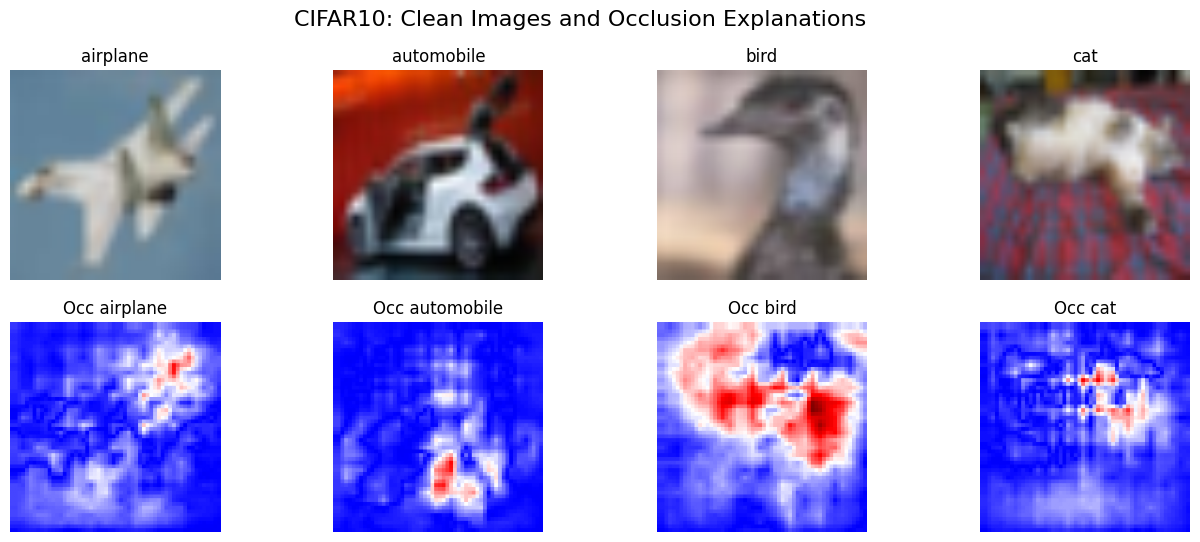

In [20]:
fig, axes = plt.subplots(
    2,
    len(selected_classes),
    figsize=(4 * len(selected_classes), 6),
)

fig.suptitle(
    "CIFAR10: Clean Images and Occlusion Explanations",
    fontsize=16,
)

for col, class_id in enumerate(selected_classes):
    clean_tensor = clean_examples_vis[class_id].unsqueeze(0).to(device)

    attr_occ = occ_experiment_vis.explainer.explain(
        input_tensor=clean_tensor,
        target_class=class_id,
    )["abs"]

    plot_image(
        axes[0, col],
        tensor_to_img(clean_tensor),
        title=f"{occ_experiment_vis.class_names[class_id]}",
        cmap=None,
    )

    plot_image(
        axes[1, col],
        attr_occ,
        title=f"Occ {occ_experiment_vis.class_names[class_id]}",
        cmap="seismic",
        vmin=occ_vmin,
        vmax=occ_vmax,
    )


## Occlusion danych niezaszumionych oraz zaszumionych

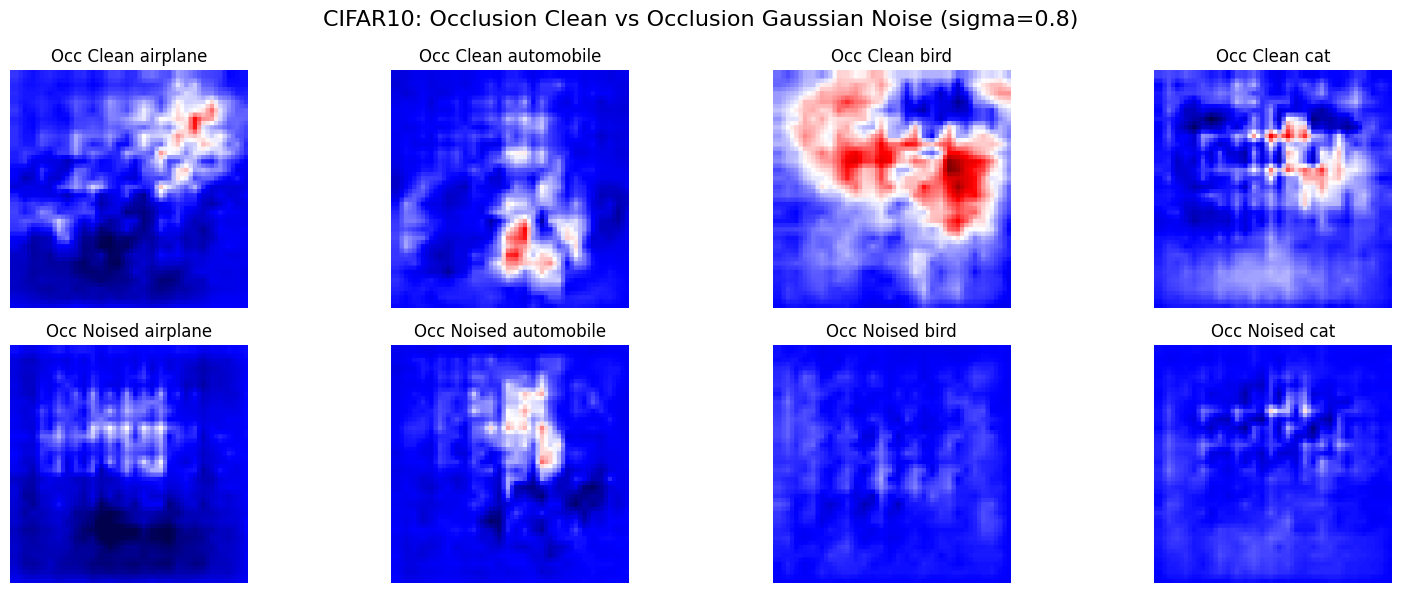

In [ ]:
fig, axes = plt.subplots(
    2,
    len(selected_classes),
    figsize=(4 * len(selected_classes), 6),
)

fig.suptitle(
    f"CIFAR10: Occlusion Clean vs FGSM Attack (epsilon={epsilon})",
    fontsize=16,
)

for col, class_id in enumerate(selected_classes):
    clean_tensor = clean_examples_vis[class_id].unsqueeze(0).to(device)

    noised_tensor = occ_experiment_vis.perturbations.gaussian(
        input_tensor=clean_tensor,
        sigma=epsilon,
    )

    attr_occ_clean = occ_experiment_vis.explainer.explain(
        input_tensor=clean_tensor,
        target_class=class_id,
    )["raw"]

    attr_occ_noised = occ_experiment_vis.explainer.explain(
        input_tensor=noised_tensor,
        target_class=class_id,
    )["raw"]

    plot_image(
        axes[0, col],
        attr_occ_clean,
        title=f"Occ Clean {occ_experiment_vis.class_names[class_id]}",
        cmap="seismic",
        vmin=occ_vmin,
        vmax=occ_vmax,
    )

    plot_image(
        axes[1, col],
        attr_occ_noised,
        title=f"Occ Noised {occ_experiment_vis.class_names[class_id]}",
        cmap="seismic",
        vmin=occ_vmin,
        vmax=occ_vmax,
    )

plt.tight_layout()
plt.show()

## Cosine Similarity oraz TopK IoU (Occlusion)

In [ ]:
df_occ_similarity = occ_experiment.run_similarity_metrics(
    perturbation_type="gaussian",
    values=config.ExperimentConfig().gaussian_sigmas,
)

display(
    occ_experiment.make_pivot(
        df_occ_similarity,
        "CosineSimilarity",
    ).round(3)
)

display(
    occ_experiment.make_pivot(
        df_occ_similarity,
        "TopK_IoU",
    ).round(3)
)

display(occ_experiment.summarize_similarity(df_occ_similarity).round(3))

Processing gaussian=0.01
Processing gaussian=0.03


## Deletion AUC (Occlusion)

In [42]:
df_occ_deletion = occ_experiment.run_deletion_auc(
    perturbation_type="gaussian",
    values=config.ExperimentConfig().gaussian_sigmas,
)

display(
    occ_experiment.make_pivot(
        df_occ_deletion,
        "DeletionAUC_Perturbed",
    ).round(3)
)

display(occ_experiment.summarize_deletion(df_occ_deletion).round(3))

Processing gaussian=0.01
Processing gaussian=0.03
Processing gaussian=0.05
Processing gaussian=0.075
Processing gaussian=0.1
Processing gaussian=0.15
Processing gaussian=0.2
Processing gaussian=0.3
Processing gaussian=0.5
Processing gaussian=0.8


ClassName,airplane,automobile,bird,cat
Value,,,,
0.010,0.436,0.296,0.038,0.249
0.030,0.541,0.321,0.031,0.254
0.050,0.357,0.298,0.059,0.224
0.075,0.252,0.296,0.050,0.217
0.100,0.253,0.477,0.213,0.237
0.150,0.344,0.338,0.100,0.142
0.200,0.339,0.513,0.051,0.065
0.300,0.538,0.421,0.211,0.020
0.500,0.113,0.140,0.012,0.018


,Value,CleanAUCMean,CleanAUCStd,PerturbedAUCMean,PerturbedAUCStd,CleanTargetConfidenceMean,PerturbedTargetConfidenceMean,PredictionChanges
0,0.010,0.263,0.172,0.255,0.165,0.999,0.999,0
1,0.030,0.263,0.172,0.287,0.210,0.999,0.999,0
2,0.050,0.263,0.172,0.235,0.129,0.999,0.998,0
3,0.075,0.263,0.172,0.204,0.107,0.999,0.998,0
4,0.100,0.263,0.172,0.295,0.122,0.999,0.999,0
5,0.150,0.263,0.172,0.231,0.128,0.999,0.883,0
6,0.200,0.263,0.172,0.242,0.224,0.999,0.661,0
7,0.300,0.263,0.172,0.297,0.229,0.999,0.389,3
8,0.500,0.263,0.172,0.071,0.065,0.999,0.378,3
9,0.800,0.263,0.172,0.102,0.140,0.999,0.147,3
